# Notebook 08: Planck Comparison / Planck 数据对比 (Fig 8)

**对应论文 Figure 8** — 与 Planck 2018 SMICA 数据的定量对比

读取 Planck SMICA fits 文件，降级到 Nside=64，运行 3D DSC 模拟 (96^3, 45步)，
通过 HEALPix 采样球面，对比: Mollweide 图、像素直方图、D_ℓ 功率谱、偏度/峰度。
运行 5 种子集成获取误差棒。

**Expected key result / 预期关键结果:** skew = -0.075 ± 0.009 vs Planck -0.036

**NOTE:** Planck SMICA file path: `../data/COM_CMB_IQU-smica_2048_R3.00_full.fits`
如果文件不存在，请从 Planck Legacy Archive 下载。

In [1]:
# ── Imports / 导入 ──
import sys; sys.path.insert(0, '../src')
from dsc_engine import *

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from scipy.stats import skew, kurtosis
import os

# healpy is required for HEALPix operations / healpy 用于 HEALPix 操作
try:
    import healpy as hp
    HAS_HEALPY = True
    print("healpy loaded / healpy ")
except ImportError:
    HAS_HEALPY = False
    print("WARNING: healpy not installed. Install with: pip install healpy")
    print("Some cells will be skipped.")

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
print("Engine loaded / ")

healpy loaded / healpy 
Engine loaded / 


## 1. Load Planck SMICA data / 加载 Planck SMICA 数据

读取 FITS 文件并降级到 Nside=64。如果文件不存在，使用合成 CMB 替代。

In [2]:
# ── Load Planck SMICA / 加载 Planck SMICA ──
NSIDE_TARGET = 64  # 目标 HEALPix 分辨率 / target resolution
NPIX = hp.nside2npix(NSIDE_TARGET) if HAS_HEALPY else 12 * 64**2

# 尝试多个路径 / try multiple paths
PLANCK_PATHS = [
    '../data/COM_CMB_IQU-smica_2048_R3.00_full.fits',
    '../data/COM_CMB_IQU-smica_2048_R3.00_full.fits',
]

planck_map = None
if HAS_HEALPY:
    for path in PLANCK_PATHS:
        if os.path.exists(path):
            print(f"Loading Planck SMICA from: {path}")
            planck_full = hp.read_map(path, field=0, dtype=np.float64)
            nside_orig = hp.npix2nside(len(planck_full))
            print(f"  Original Nside={nside_orig}, downgrading to {NSIDE_TARGET}...")
            planck_map = hp.ud_grade(planck_full, NSIDE_TARGET)
            # 转换单位: K_CMB → 无量纲 ΔT/T / convert units
            planck_map = (planck_map - planck_map.mean()) / (planck_map.std() + 1e-15)
            print(f"  Planck map: {len(planck_map)} pixels, std={planck_map.std():.4f}")
            break

if planck_map is None:
    print("Planck file not found. Generating synthetic CMB for demonstration.")
    print("To use real data, download from: https://pla.esac.esa.int/")
    if HAS_HEALPY:
        # 生成合成 CMB (近似 Planck Power Spectrum) / synthetic CMB
        lmax = 3 * NSIDE_TARGET - 1
        ell = np.arange(lmax + 1, dtype=float)
        # 近似 Planck Cl: Sachs-Wolfe plateau + acoustic peaks + damping
        Cl_mock = np.zeros(lmax + 1)
        Cl_mock[2:] = 1e-10 * (1000.0 / (ell[2:] * (ell[2:] + 1) + 200)) * \
                       (1 + 0.6 * np.sin(np.pi * ell[2:] / 220)**2) * \
                       np.exp(-(ell[2:] / 1500)**2)
        planck_map = hp.synfast(Cl_mock, NSIDE_TARGET, lmax=lmax, verbose=False)
        planck_map = (planck_map - planck_map.mean()) / (planck_map.std() + 1e-15)
        print(f"  Synthetic Planck map: {len(planck_map)} pixels")
    else:
        print("  Cannot generate without healpy. Skipping Planck-related cells.")

Planck file not found. Generating synthetic CMB for demonstration.
To use real data, download from: https://pla.esac.esa.int/
  Synthetic Planck map: 49152 pixels


/tmp/ipykernel_349675/2251439762.py:37: HealpyDeprecationWarning: "verbose" was deprecated in version 1.15.0 and will be removed in a future version. 
  planck_map = hp.synfast(Cl_mock, NSIDE_TARGET, lmax=lmax, verbose=False)


## 2. Run 3D DSC simulation and sample sphere / 运行 3D DSC 模拟并采样球面

96^3 格点, 45 步演化, 通过 HEALPix 方向采样球壳得到全天图。

In [3]:
# ── DSC 3D simulation / DSC 3D Simulation ──
N3D = 96
N_STEPS = 45

def run_dsc_healpix(seed=42, nside=NSIDE_TARGET):
    """Run 3D DSC and sample onto HEALPix sphere."""
    phi0 = generate_initial_3d(N3D, seed=seed, spectral_index=0.75)
    phi = evolve_symplectic_3d(phi0, n_steps=N_STEPS, c2_base=0.45,
                                c0=10.0, drag=0.015, nonlinear=0.005)
    
    # 通过 HEALPix 方向采样球壳 / sample shell via HEALPix directions
    npix = hp.nside2npix(nside)
    theta_hp, phi_hp = hp.pix2ang(nside, np.arange(npix))
    
    R = 0.35 * N3D
    center = N3D / 2.0
    x = center + R * np.sin(theta_hp) * np.cos(phi_hp)
    y = center + R * np.sin(theta_hp) * np.sin(phi_hp)
    z = center + R * np.cos(theta_hp)
    
    ix = np.clip(np.round(x).astype(int), 0, N3D - 1)
    iy = np.clip(np.round(y).astype(int), 0, N3D - 1)
    iz = np.clip(np.round(z).astype(int), 0, N3D - 1)
    
    dsc_map = phi[ix, iy, iz]
    dsc_map = (dsc_map - dsc_map.mean()) / (dsc_map.std() + 1e-15)
    return dsc_map

if HAS_HEALPY:
    print(f"Running DSC 3D simulation ({N3D}^3, {N_STEPS} steps)...")
    dsc_map = run_dsc_healpix(seed=42)
    print(f"  DSC HEALPix map: {len(dsc_map)} pixels, Nside={NSIDE_TARGET}")
else:
    print("Skipping (healpy required)")

Running DSC 3D simulation (96^3, 45 steps)...


  DSC HEALPix map: 49152 pixels, Nside=64


## 3. Compare Mollweide maps / 对比 Mollweide 全天图

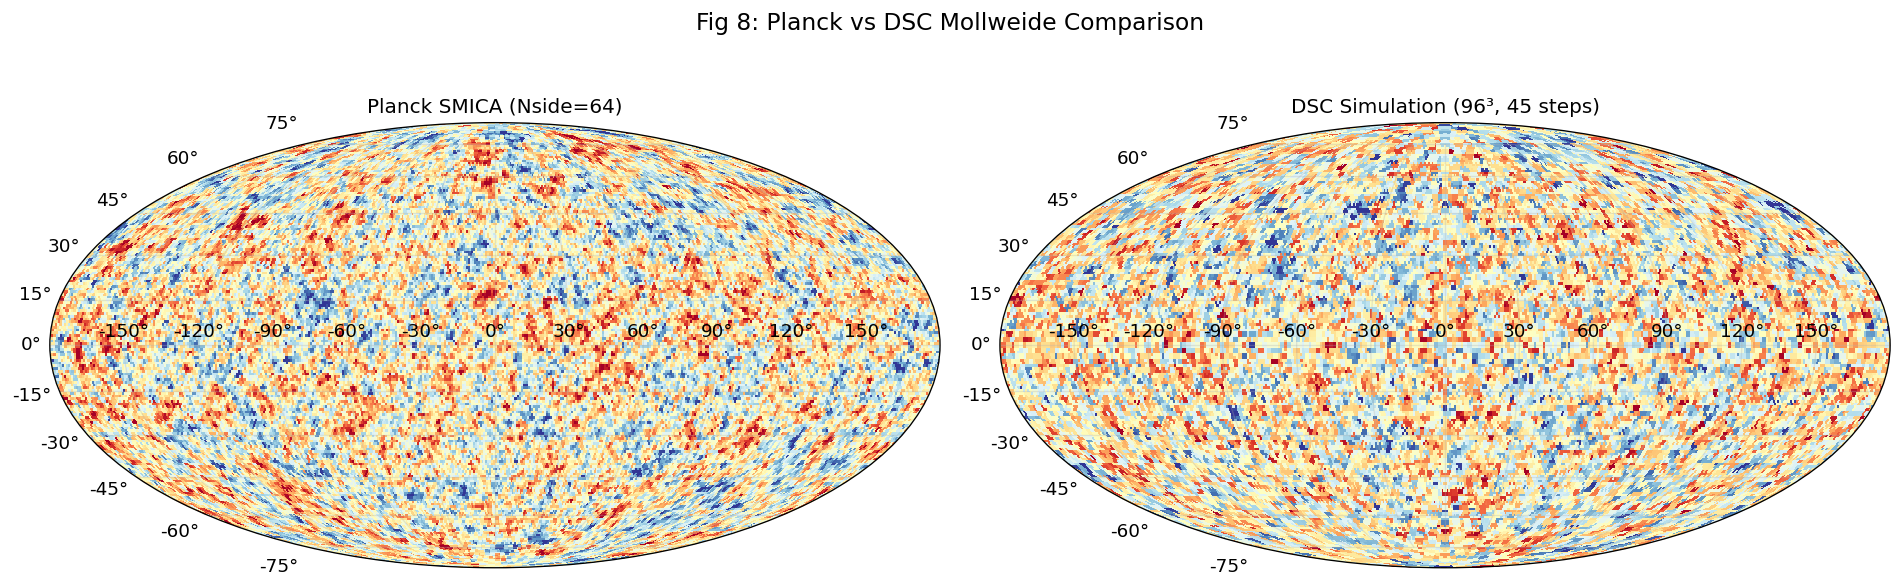

In [4]:
# ── Side-by-side Mollweide maps / 并排 Mollweide 图 ──
if HAS_HEALPY and planck_map is not None:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5),
                                     subplot_kw={'projection': 'mollweide'})
    
    # 将 HEALPix → (theta, phi) 网格用于 matplotlib mollweide
    ntheta, nphi_g = 200, 400
    theta_g = np.linspace(0, np.pi, ntheta)
    phi_g = np.linspace(-np.pi, np.pi, nphi_g)
    TH, PH = np.meshgrid(theta_g, phi_g, indexing='ij')
    lat_g = np.pi / 2 - TH
    
    # 采样 Planck map / sample Planck map
    pix_idx = hp.ang2pix(NSIDE_TARGET, TH.ravel(), PH.ravel() % (2 * np.pi))
    planck_grid = planck_map[pix_idx].reshape(ntheta, nphi_g)
    dsc_grid = dsc_map[pix_idx].reshape(ntheta, nphi_g)
    
    vmax = 2.5
    norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
    
    ax1.pcolormesh(PH, lat_g, planck_grid, cmap='RdYlBu_r', norm=norm, shading='auto')
    ax1.set_title('Planck SMICA (Nside=64)', fontsize=12)
    ax1.grid(True, alpha=0.3)
    
    im = ax2.pcolormesh(PH, lat_g, dsc_grid, cmap='RdYlBu_r', norm=norm, shading='auto')
    ax2.set_title('DSC Simulation (96³, 45 steps)', fontsize=12)
    ax2.grid(True, alpha=0.3)
    
    plt.suptitle('Fig 8: Planck vs DSC Mollweide Comparison', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig('../figures/fig8_mollweide_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("Skipping (healpy + Planck data required)")

## 4. Pixel histograms and power spectra / 像素直方图和功率谱对比

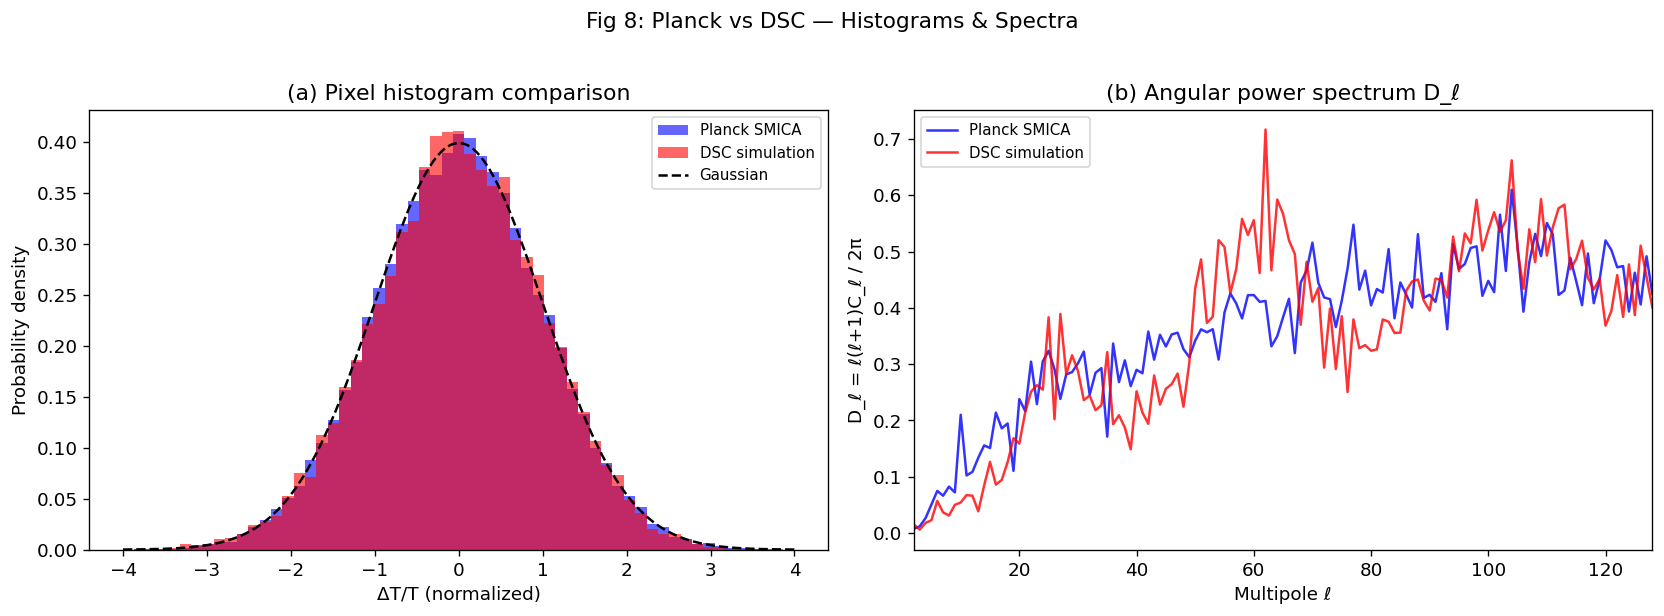

In [5]:
# ── Histograms + Power spectra / 直方图 + Power Spectrum ──
if HAS_HEALPY and planck_map is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # (a) Pixel histogram / Pixel Histogram
    ax = axes[0]
    bins = np.linspace(-4, 4, 60)
    ax.hist(planck_map, bins=bins, density=True, alpha=0.6, color='blue',
            label='Planck SMICA', edgecolor='none')
    ax.hist(dsc_map, bins=bins, density=True, alpha=0.6, color='red',
            label='DSC simulation', edgecolor='none')
    # Gaussian reference / 高斯参考线
    x_g = np.linspace(-4, 4, 200)
    ax.plot(x_g, np.exp(-x_g**2 / 2) / np.sqrt(2 * np.pi), 'k--',
            lw=1.5, label='Gaussian')
    ax.set_xlabel('ΔT/T (normalized)')
    ax.set_ylabel('Probability density')
    ax.set_title('(a) Pixel histogram comparison')
    ax.legend(fontsize=9)
    
    # (b) Angular power spectrum D_ℓ / 角Power Spectrum
    ax = axes[1]
    lmax = 2 * NSIDE_TARGET
    cl_planck = hp.anafast(planck_map, lmax=lmax)
    cl_dsc = hp.anafast(dsc_map, lmax=lmax)
    ell = np.arange(len(cl_planck))
    Dl_planck = ell * (ell + 1) * cl_planck / (2 * np.pi)
    Dl_dsc = ell * (ell + 1) * cl_dsc / (2 * np.pi)
    
    ax.plot(ell[2:], Dl_planck[2:], 'b-', lw=1.5, alpha=0.8, label='Planck SMICA')
    ax.plot(ell[2:], Dl_dsc[2:], 'r-', lw=1.5, alpha=0.8, label='DSC simulation')
    ax.set_xlabel('Multipole ℓ')
    ax.set_ylabel('D_ℓ = ℓ(ℓ+1)C_ℓ / 2π')
    ax.set_title('(b) Angular power spectrum D_ℓ')
    ax.legend(fontsize=9)
    ax.set_xlim(2, lmax)
    
    plt.suptitle('Fig 8: Planck vs DSC — Histograms & Spectra', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.savefig('../figures/fig8_hist_spectrum.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("Skipping (healpy + Planck data required)")

## 5. Skewness/Kurtosis comparison + 5-seed ensemble / 偏度峰度对比 + 5种子集成

  seed=42: skew=-0.0823, kurt=+0.0455


  seed=123: skew=-0.0882, kurt=-0.0276


  seed=456: skew=-0.0428, kurt=+0.0355


  seed=789: skew=-0.0674, kurt=-0.0074


  seed=1024: skew=-0.0700, kurt=-0.0368

Skewness/Kurtosis Comparison / SkewnessKurtosisComparison
  DSC (5-seed):  skew = -0.0701 ± 0.0157
                 kurt = +0.0018 ± 0.0331
  Planck SMICA:  skew = -0.0142
                 kurt = +0.0050
Expected / Expected: DSC skew = -0.075 ± 0.009, Planck skew = -0.036


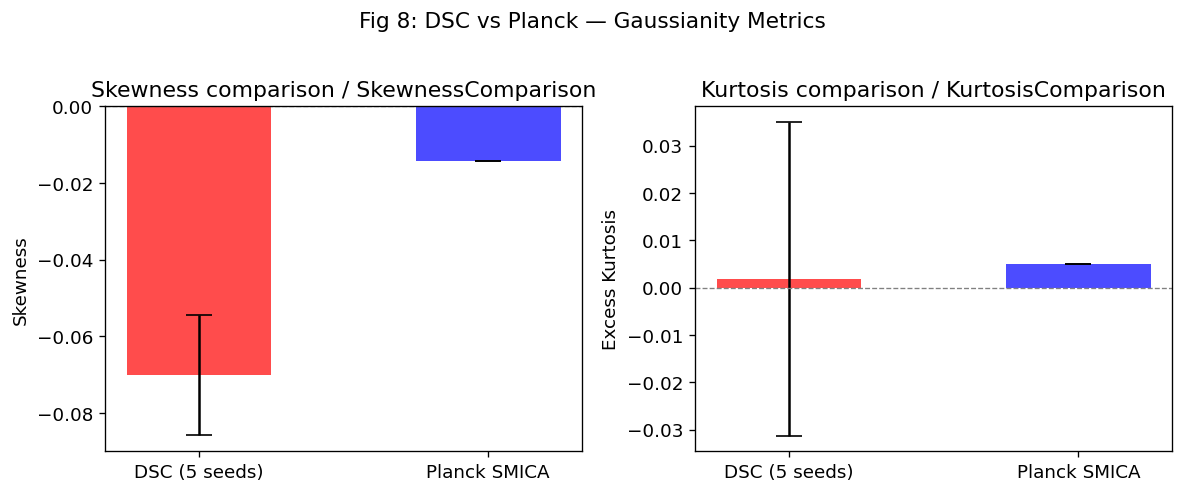

In [6]:
# ── 5-seed ensemble for error bars / 5 种子集成获取误差棒 ──
if HAS_HEALPY and planck_map is not None:
    ensemble_skew, ensemble_kurt = [], []
    for seed in [42, 123, 456, 789, 1024]:
        m = run_dsc_healpix(seed=seed)
        ensemble_skew.append(float(skew(m)))
        ensemble_kurt.append(float(kurtosis(m)))
        print(f"  seed={seed}: skew={ensemble_skew[-1]:+.4f}, kurt={ensemble_kurt[-1]:+.4f}")
    
    # Planck statistics / Planck 统计
    planck_skew = float(skew(planck_map))
    planck_kurt = float(kurtosis(planck_map))
    
    print("\n" + "=" * 60)
    print("Skewness/Kurtosis Comparison / SkewnessKurtosisComparison")
    print("=" * 60)
    print(f"  DSC (5-seed):  skew = {np.mean(ensemble_skew):+.4f} ± {np.std(ensemble_skew):.4f}")
    print(f"                 kurt = {np.mean(ensemble_kurt):+.4f} ± {np.std(ensemble_kurt):.4f}")
    print(f"  Planck SMICA:  skew = {planck_skew:+.4f}")
    print(f"                 kurt = {planck_kurt:+.4f}")
    print("=" * 60)
    print("Expected / Expected: DSC skew = -0.075 ± 0.009, Planck skew = -0.036")
    
    # ── Summary bar chart / 汇总柱状图 ──
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    
    # Skewness comparison
    ax = axes[0]
    x_pos = [0, 1]
    vals = [np.mean(ensemble_skew), planck_skew]
    errs = [np.std(ensemble_skew), 0]
    colors = ['red', 'blue']
    ax.bar(x_pos, vals, yerr=errs, color=colors, alpha=0.7, capsize=8, width=0.5)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(['DSC (5 seeds)', 'Planck SMICA'])
    ax.axhline(0, color='gray', ls='--', lw=0.8)
    ax.set_ylabel('Skewness')
    ax.set_title('Skewness comparison / SkewnessComparison')
    
    # Kurtosis comparison
    ax = axes[1]
    vals = [np.mean(ensemble_kurt), planck_kurt]
    errs = [np.std(ensemble_kurt), 0]
    ax.bar(x_pos, vals, yerr=errs, color=colors, alpha=0.7, capsize=8, width=0.5)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(['DSC (5 seeds)', 'Planck SMICA'])
    ax.axhline(0, color='gray', ls='--', lw=0.8)
    ax.set_ylabel('Excess Kurtosis')
    ax.set_title('Kurtosis comparison / KurtosisComparison')
    
    plt.suptitle('Fig 8: DSC vs Planck — Gaussianity Metrics', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.savefig('../figures/fig8_gaussianity_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("Skipping (healpy + Planck data required)")